# **Lab 05.2 - Continuous and Policy-Based RL with DDPG and PPO**


##### Copyright by UIT-NC@NT549

## **Some instructions before getting started**:
<div style="font-family: 'Arial'; font-size: 16px; line-height: 1.6; text-align: justify;">

Start the Kernel: At the top right, choose <strong>Select Kernel ➞ Python Environments...</strong>

You can run all code blocks to check: From the menu bar, choose <strong>Run All</strong>.

Complete all code blocks marked with the comment <span style="font-family: monospace; font-weight: bold; color:white; background-color: green;"> ### YOU NEED TO WRITE YOUR CODE BELOW ### </span>
  
This lab contains the following practical parts:
1. Part 1,2 — Build and validate the EdgeOffloadingEnv (device vs. edge).
2. Part 3 — Implement baseline policies (random, device-only, edge-only, greedy).
3. Part 4 — A2C
4. Part 5 — PPO
6. Part 6 — Final comparison and analysis of all methods.


In [10]:
# ============================================================================
# Imports and runtime stability config
# ============================================================================

import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical

# Limit PyTorch threading for kernel stability on macOS
torch.set_num_threads(1)
try:
    torch.set_num_interop_threads(1)
except RuntimeError:
    pass

# Reproducibility
SEED = 42
FAST_MODE = True
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Device info
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'PyTorch: {torch.__version__}')
print(f'NumPy: {np.__version__}')
print(f'Gymnasium: {gym.__version__}')
print(f'FAST_MODE: {FAST_MODE}')

# Shared plotting helpers
plt.rcParams.update({
    'figure.figsize': (10, 4),
    'axes.grid': True,
    'grid.alpha': 0.25,
})

def moving_average(values, window=20):
    """Smooth a learning curve using a moving average."""
    if len(values) == 0:
        return np.array([])
    return pd.Series(values).rolling(window=window, min_periods=1).mean().to_numpy()


def plot_curve(values, title, ylabel, window=20):
    """Plot raw values together with a moving average."""
    x = np.arange(1, len(values) + 1)
    plt.figure(figsize=(10, 4))
    plt.plot(x, values, alpha=0.35, label='Episode value')
    plt.plot(x, moving_average(values, window), lw=2, label=f'{window}-episode moving average')
    plt.title(title)
    plt.xlabel('Episode')
    plt.ylabel(ylabel)
    plt.legend()
    plt.tight_layout()
    plt.show()


def evaluate_edge_policy(env_fn, action_fn, episodes=100):
    """Evaluate a policy on EdgeOffloadingEnv and return summary metrics."""
    episode_rewards, episode_avg_latencies, all_latencies = [], [], []
    action_counts = np.zeros(2, dtype=np.int64)

    for ep in range(episodes):
        env = env_fn(SEED + 2000 + ep)
        state, _ = env.reset(seed=SEED + 2000 + ep)

        done = False
        rewards, latencies = [], []

        while not done:
            action = int(action_fn(state, env))
            state, reward, terminated, truncated, info = env.step(action)
            rewards.append(reward)
            latencies.append(info['latency'])
            action_counts[action] += 1
            done = terminated or truncated

        env.close()
        episode_rewards.append(float(np.sum(rewards)))
        episode_avg_latencies.append(float(np.mean(latencies)))
        all_latencies.extend(latencies)

    all_latencies = np.array(all_latencies, dtype=np.float32)
    total_actions = int(action_counts.sum())

    return {
        'episode_rewards': np.array(episode_rewards, dtype=np.float32),
        'episode_avg_latencies': np.array(episode_avg_latencies, dtype=np.float32),
        'all_latencies': all_latencies,
        'action_counts': action_counts,
        'avg_latency': float(np.mean(all_latencies)),
        'p95_latency': float(np.percentile(all_latencies, 95)),
        'avg_reward': float(np.mean(episode_rewards)),
        'device_pct': float(action_counts[0] / total_actions * 100.0),
        'edge_pct': float(action_counts[1] / total_actions * 100.0),
    }

Device: cpu
PyTorch: 2.11.0+cu130
NumPy: 1.26.4
Gymnasium: 0.29.1
FAST_MODE: True


In [11]:

print("\n" + "="*60)
print("PART 1: EDGE OFFLOADING ENVIRONMENT")
print("="*60)

class EdgeOffloadingEnv(gym.Env):
    """Custom edge offloading environment for RL training.

    State: [input_size, workload, uplink_rate, edge_queue]
    Actions: 0 = device execution, 1 = edge offloading
    Reward: -latency/MAX_LATENCY, so maximizing reward minimizes latency.
    """

    metadata = {'render_modes': ['human']}

    def __init__(self, max_steps=50):
        super().__init__()
        self.max_steps = int(max_steps)
        self.f_device = 1.0  # GHz
        self.f_edge = 5.0    # GHz
        self.max_latency = 11000.0  # Upper-bound normalization constant in milliseconds.

        self.low = np.array([1.0, 0.1, 2.0, 0.0], dtype=np.float32)
        self.high = np.array([20.0, 3.0, 20.0, 200.0], dtype=np.float32)
        self.observation_space = spaces.Box(low=self.low, high=self.high, dtype=np.float32)
        self.action_space = spaces.Discrete(2)

        self.state = None
        self.step_count = 0

    def _sample_state(self):
        """Sample [input_size, workload, uplink_rate, edge_queue]."""
        return self.np_random.uniform(self.low, self.high).astype(np.float32)

    def _compute_latencies(self, state):
        """Return device and edge latency in milliseconds."""
        input_size, workload, uplink_rate, edge_queue = np.asarray(state, dtype=np.float32)
        latency_device = (workload / self.f_device) * 1000.0
        upload_latency = (input_size / uplink_rate) * 1000.0
        latency_edge = upload_latency + edge_queue + (workload / self.f_edge) * 1000.0
        return float(latency_device), float(latency_edge)

    def _build_info(self, action=None, latency=None):
        latency_device, latency_edge = self._compute_latencies(self.state)
        if action is None:
            selected_latency = latency
            action_name = None
        else:
            selected_latency = latency_device if int(action) == 0 else latency_edge
            action_name = 'device' if int(action) == 0 else 'edge'

        return {
            'latency': float(selected_latency) if selected_latency is not None else None,
            'latency_device': float(latency_device),
            'latency_edge': float(latency_edge),
            'action': None if action is None else int(action),
            'action_name': action_name,
            'step_count': int(self.step_count),
        }

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.step_count = 0
        self.state = self._sample_state()
        return self.state.copy(), self._build_info()

    def step(self, action):
        if self.state is None:
            raise RuntimeError('Call reset() before step().')
        if not self.action_space.contains(int(action)):
            raise ValueError(f'Invalid action {action}. Expected 0=device or 1=edge.')

        action = int(action)
        latency_device, latency_edge = self._compute_latencies(self.state)
        selected_latency = latency_device if action == 0 else latency_edge
        reward = -selected_latency / self.max_latency

        info = {
            'latency': float(selected_latency),
            'latency_device': float(latency_device),
            'latency_edge': float(latency_edge),
            'action': action,
            'action_name': 'device' if action == 0 else 'edge',
            'step_count': int(self.step_count + 1),
        }

        self.step_count += 1
        terminated = False
        truncated = self.step_count >= self.max_steps
        self.state = self._sample_state()
        return self.state.copy(), float(reward), terminated, truncated, info

    def render(self):
        """Render current environment state."""
        if self.state is None:
            print('Environment has not been reset yet.')
        else:
            print(f'Step {self.step_count:02d} | state = {np.round(self.state, 3)}')


# Test environment initialization
print("\nInitializing EdgeOffloadingEnv...")
edge_env = EdgeOffloadingEnv(max_steps=50)
obs, info = edge_env.reset(seed=SEED)
print(f'Initial observation: {np.round(obs, 3)}')
print(f'Initial info: {info}')



PART 1: EDGE OFFLOADING ENVIRONMENT

Initializing EdgeOffloadingEnv...
Initial observation: [ 15.705   1.373  17.455 139.474]
Initial info: {'latency': None, 'latency_device': 1372.7474212646484, 'latency_edge': 1313.7869091033936, 'action': None, 'action_name': None, 'step_count': 0}


---

# PART 2: Environment Validation

Before training any policy, we validate environment API behavior and inspect transition outputs using a short random rollout.

In [12]:
# Environment validation and simple rollout test
print("\nValidating environment...")
try:
    from gymnasium.utils.env_checker import check_env
    check_env(edge_env, skip_render_check=True)
    print("✓ check_env passed successfully.")
except Exception as exc:
    print(f"check_env not available or skipped. Details: {exc}")

# Run a few steps to verify correctness
print("\nTest rollout (5 steps):")
obs, info = edge_env.reset(seed=SEED)
print(f"Initial obs: {np.round(obs, 3)}")

for step_idx in range(5):
    action = edge_env.action_space.sample()
    obs, reward, terminated, truncated, info = edge_env.step(action)
    print(f"Step {step_idx + 1}: action={action}, "
          f"reward={reward:.6f}, "
          f"latency={info['latency']:.2f}ms, "
          f"action_name={info['action_name']}")
    
    if terminated or truncated:
        obs, info = edge_env.reset(seed=SEED + step_idx + 1)
        print("  → Episode truncated, reset.")



Validating environment...
✓ check_env passed successfully.

Test rollout (5 steps):
Initial obs: [ 15.705   1.373  17.455 139.474]
Step 1: action=1, reward=-0.119435, latency=1313.79ms, action_name=edge
Step 2: action=1, reward=-0.083703, latency=920.73ms, action_name=edge
Step 3: action=1, reward=-0.078407, latency=862.47ms, action_name=edge
Step 4: action=1, reward=-0.169859, latency=1868.45ms, action_name=edge
Step 5: action=1, reward=-0.078738, latency=866.12ms, action_name=edge


---

# PART 3: Baseline Policies and Evaluation

Before training RL algorithms, we establish baseline policies to understand expected latency and reward scales.

### 3.1 Policy Implementations

We implement four baseline policies:
- **Random**: choose action uniformly at random
- **Device-only**: always execute on device
- **Edge-only**: always offload to edge
- **Greedy latency**: choose action with lower immediate latency


In [13]:

# ============================================================================
# Baseline policy functions
# ============================================================================

EDGE_MAX_STEPS = 50
EVAL_EPISODES = 100 if not FAST_MODE else 50
A2C_EPISODES = 350 if not FAST_MODE else 180
PPO_UPDATES = 120 if not FAST_MODE else 100
PPO_ROLLOUT_STEPS = 1024 if not FAST_MODE else 512

STATE_SCALE = np.array([20.0, 3.0, 20.0, 200.0], dtype=np.float32)


def make_edge_env(seed=None, max_steps=EDGE_MAX_STEPS):
    env = EdgeOffloadingEnv(max_steps=max_steps)
    if seed is not None:
        env.reset(seed=seed)
    return env


def normalize_state(state):
    return np.asarray(state, dtype=np.float32) / STATE_SCALE


def random_policy(state, env):
    return env.action_space.sample()


def device_only_policy(state, env):
    return 0


def edge_only_policy(state, env):
    return 1


def greedy_latency_policy(state, env):
    latency_device, latency_edge = env._compute_latencies(state)
    return int(latency_edge < latency_device)


def greedy_targets_from_normalized_tensor(state_tensor):
    scale_tensor = torch.tensor(STATE_SCALE, dtype=torch.float32, device=state_tensor.device)
    raw_state_tensor = state_tensor * scale_tensor
    input_size = raw_state_tensor[:, 0]
    workload = raw_state_tensor[:, 1]
    uplink_rate = raw_state_tensor[:, 2]
    edge_queue = raw_state_tensor[:, 3]
    latency_device = workload * 1000.0
    latency_edge = (input_size / uplink_rate) * 1000.0 + edge_queue + (workload / 5.0) * 1000.0
    return (latency_edge < latency_device).long()


def sample_greedy_training_data(sample_count=4096, seed=SEED):
    rng = np.random.default_rng(seed)
    raw_states = rng.uniform(
        low=np.array([1.0, 0.1, 2.0, 0.0], dtype=np.float32),
        high=np.array([20.0, 3.0, 20.0, 200.0], dtype=np.float32),
        size=(sample_count, 4),
    ).astype(np.float32)
    normalized_states = raw_states / STATE_SCALE
    latency_device = raw_states[:, 1] * 1000.0
    latency_edge = (raw_states[:, 0] / raw_states[:, 2]) * 1000.0 + raw_states[:, 3] + (raw_states[:, 1] / 5.0) * 1000.0
    greedy_actions = (latency_edge < latency_device).astype(np.int64)
    return normalized_states, greedy_actions


def warm_start_with_greedy_policy(model, optimizer, sample_count=4096, epochs=20, batch_size=256, seed=SEED):
    states, actions = sample_greedy_training_data(sample_count=sample_count, seed=seed)
    state_tensor = torch.tensor(states, dtype=torch.float32, device=device)
    action_tensor = torch.tensor(actions, dtype=torch.long, device=device)
    index_array = np.arange(sample_count)
    losses = []

    for _ in range(epochs):
        np.random.shuffle(index_array)
        batch_losses = []
        for start in range(0, sample_count, batch_size):
            batch_idx = index_array[start:start + batch_size]
            logits, _ = model(state_tensor[batch_idx])
            loss = nn.CrossEntropyLoss()(logits, action_tensor[batch_idx])
            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 0.5)
            optimizer.step()
            batch_losses.append(float(loss.item()))
        losses.append(float(np.mean(batch_losses)))
    return losses


baseline_policy_functions = {
    'Random': random_policy,
    'Device-only': device_only_policy,
    'Edge-only': edge_only_policy,
    'Greedy latency': greedy_latency_policy,
}

print('Baseline policies ready:', ', '.join(baseline_policy_functions.keys()))


Baseline policies ready: Random, Device-only, Edge-only, Greedy latency


In [14]:

# ============================================================================
# Evaluate baseline policies
# ============================================================================

baseline_results = {}
for policy_name, policy_fn in baseline_policy_functions.items():
    baseline_results[policy_name] = evaluate_edge_policy(
        lambda seed: make_edge_env(seed),
        policy_fn,
        episodes=EVAL_EPISODES,
    )

baseline_table = pd.DataFrame([
    {
        'Method': name,
        'Avg Latency (ms)': result['avg_latency'],
        'P95 Latency (ms)': result['p95_latency'],
        'Avg Reward': result['avg_reward'],
        'Device %': result['device_pct'],
        'Edge %': result['edge_pct'],
    }
    for name, result in baseline_results.items()
]).sort_values('Avg Latency (ms)')

print('Baseline evaluation completed.')
baseline_table


Baseline evaluation completed.


,Method,Avg Latency (ms),P95 Latency (ms),Avg Reward,Device %,Edge %
3,Greedy latency,1146.594849,2367.024194,-5.211795,48.68,51.32
1,Device-only,1547.224243,2848.060632,-7.032838,100.00,0.00
0,Random,1651.593018,3196.881055,-7.507241,48.88,51.12
2,Edge-only,1762.060791,4489.289941,-8.009367,0.00,100.00


---

# PART 4: A2C 


### 6.1 A2C Training and Evaluation


In [15]:

# ============================================================================
# Actor-Critic / A2C training analysis
# ============================================================================

class ActorCriticNetwork(nn.Module):
    def __init__(self, state_dim=4, action_dim=2, hidden_size=128):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(state_dim, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
        )
        self.policy_head = nn.Linear(hidden_size, action_dim)
        self.value_head = nn.Linear(hidden_size, 1)

    def forward(self, state_tensor):
        features = self.shared(state_tensor)
        return self.policy_head(features), self.value_head(features)


def discount_returns(rewards, gamma=0.99):
    returns = []
    running_return = 0.0
    for reward in reversed(rewards):
        running_return = float(reward) + gamma * running_return
        returns.insert(0, running_return)
    return np.asarray(returns, dtype=np.float32)


def train_a2c_edge(
    episodes=A2C_EPISODES,
    gamma=0.99,
    learning_rate=1e-4,
    entropy_coef=0.01,
    value_coef=0.5,
    imitation_coef=0.15,
):
    model = ActorCriticNetwork().to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    pretrain_losses = warm_start_with_greedy_policy(
        model,
        optimizer,
        sample_count=4096,
        epochs=20,
        seed=SEED + 100,
    )
    print(f'A2C greedy warm-start final CE loss: {pretrain_losses[-1]:.4f}')
    episode_rewards, episode_avg_latencies, losses = [], [], []

    for episode in range(episodes):
        env = make_edge_env(SEED + episode)
        state, _ = env.reset(seed=SEED + episode)
        state_norms, log_probs, values, rewards, entropies, latencies = [], [], [], [], [], []
        done = False

        while not done:
            normalized_state = normalize_state(state)
            state_norms.append(normalized_state)
            state_tensor = torch.tensor(normalized_state, dtype=torch.float32, device=device).unsqueeze(0)
            logits, value = model(state_tensor)
            distribution = Categorical(logits=logits)
            action = distribution.sample()
            next_state, reward, terminated, truncated, info = env.step(int(action.item()))

            log_probs.append(distribution.log_prob(action))
            values.append(value.squeeze(0).squeeze(-1))
            rewards.append(float(reward))
            entropies.append(distribution.entropy())
            latencies.append(info['latency'])

            state = next_state
            done = terminated or truncated

        env.close()
        returns = torch.tensor(discount_returns(rewards, gamma), dtype=torch.float32, device=device)
        values_tensor = torch.stack(values)
        log_probs_tensor = torch.stack(log_probs)
        entropy_tensor = torch.stack(entropies)
        advantages = returns - values_tensor.detach()
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        policy_loss = -(log_probs_tensor * advantages).mean()
        value_loss = nn.MSELoss()(values_tensor, returns)
        entropy_bonus = entropy_tensor.mean()
        episode_state_tensor = torch.tensor(np.asarray(state_norms), dtype=torch.float32, device=device)
        imitation_logits, _ = model(episode_state_tensor)
        imitation_targets = greedy_targets_from_normalized_tensor(episode_state_tensor)
        imitation_loss = nn.CrossEntropyLoss()(imitation_logits, imitation_targets)
        loss = policy_loss + value_coef * value_loss - entropy_coef * entropy_bonus + imitation_coef * imitation_loss

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 0.5)
        optimizer.step()

        episode_rewards.append(float(np.sum(rewards)))
        episode_avg_latencies.append(float(np.mean(latencies)))
        losses.append(float(loss.item()))

        if (episode + 1) % 30 == 0 or episode == 0:
            print(
                f'A2C episode {episode + 1:03d}/{episodes} | '
                f'return={episode_rewards[-1]:.3f} | '
                f'avg_latency={episode_avg_latencies[-1]:.2f}ms'
            )

    return model, {
        'episode_rewards': np.array(episode_rewards, dtype=np.float32),
        'episode_avg_latencies': np.array(episode_avg_latencies, dtype=np.float32),
        'losses': np.array(losses, dtype=np.float32),
    }


def a2c_policy_action(state, env, model):
    state_tensor = torch.tensor(normalize_state(state), dtype=torch.float32, device=device).unsqueeze(0)
    with torch.no_grad():
        logits, _ = model(state_tensor)
    return int(torch.argmax(logits, dim=1).item())



PART 5: A2C TRAINING AND EVALUATION
A2C greedy warm-start final CE loss: 0.2536
A2C episode 001/180 | return=-6.257 | avg_latency=1376.47ms
A2C episode 030/180 | return=-4.957 | avg_latency=1090.60ms
A2C episode 060/180 | return=-5.542 | avg_latency=1219.23ms
A2C episode 090/180 | return=-6.149 | avg_latency=1352.86ms
A2C episode 120/180 | return=-5.553 | avg_latency=1221.58ms
A2C episode 150/180 | return=-6.556 | avg_latency=1442.23ms
A2C episode 180/180 | return=-5.990 | avg_latency=1317.81ms


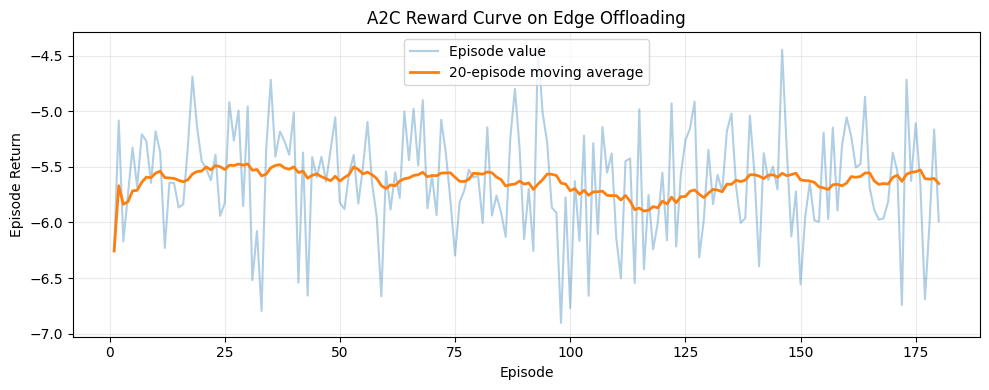

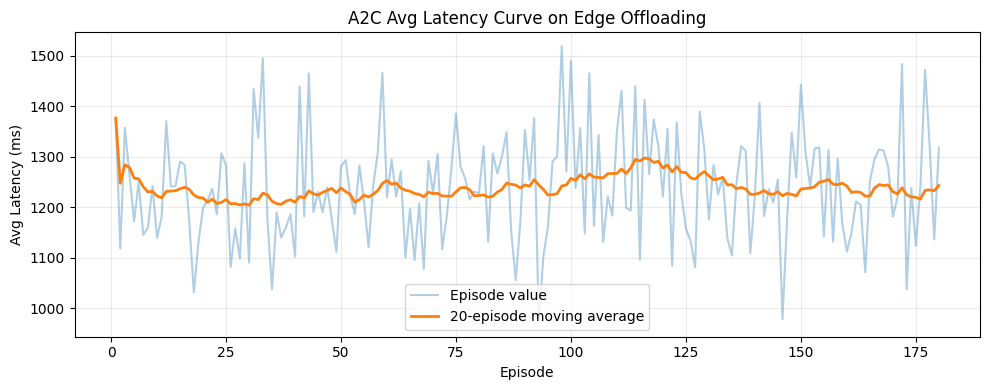

A2C evaluation summary:
{'avg_latency': 1166.89, 'p95_latency': 2402.071, 'avg_reward': -5.304, 'device_pct': 47.88, 'edge_pct': 52.12}


In [16]:

print("\n" + "="*60)
print("PART 5: A2C TRAINING AND EVALUATION")
print("="*60)

# A2C training and evaluation
a2c_model, a2c_training = train_a2c_edge()

a2c_results = evaluate_edge_policy(
    lambda seed: make_edge_env(seed),
    lambda state, env: a2c_policy_action(state, env, a2c_model),
    episodes=EVAL_EPISODES,
)

plot_curve(a2c_training['episode_rewards'], 'A2C Reward Curve on Edge Offloading', 'Episode Return', window=20)
plot_curve(a2c_training['episode_avg_latencies'], 'A2C Avg Latency Curve on Edge Offloading', 'Avg Latency (ms)', window=20)

print('A2C evaluation summary:')
print({
    'avg_latency': round(a2c_results['avg_latency'], 3),
    'p95_latency': round(a2c_results['p95_latency'], 3),
    'avg_reward': round(a2c_results['avg_reward'], 3),
    'device_pct': round(a2c_results['device_pct'], 2),
    'edge_pct': round(a2c_results['edge_pct'], 2),
})


---

# PART 5: PPO on EdgeOffloadingEnv

**Pipeline Architecture**:
1. Feed edge state tensors into shared feature blocks.
2. Produce offloading-action logits via `ppo_scratch_policy_net`.
3. Produce scalar baseline via `ppo_scratch_value_net`.
4. Sample actions from Categorical logits for on-policy exploration.

**Component Interactions**:
- Policy and value heads share encoded system-state features.
- Outputs are consumed by rollout collection and PPO optimization below.

**Mathematical/Algorithmic Anchors**:
- Categorical stochastic policy over offloading decisions.
- Baseline value estimate for advantage reduction.



PART 5: PPO ON EDGE OFFLOADING ENV
PPO greedy warm-start final CE loss: 0.1660
PPO update 001/100 | recent_return=-5.331 | recent_latency=1172.92ms | loss=1.0228
PPO update 005/100 | recent_return=-5.307 | recent_latency=1167.51ms | loss=0.9479
PPO early stopping at update 7; restored best checkpoint from update 3 (recent_return=-5.131).


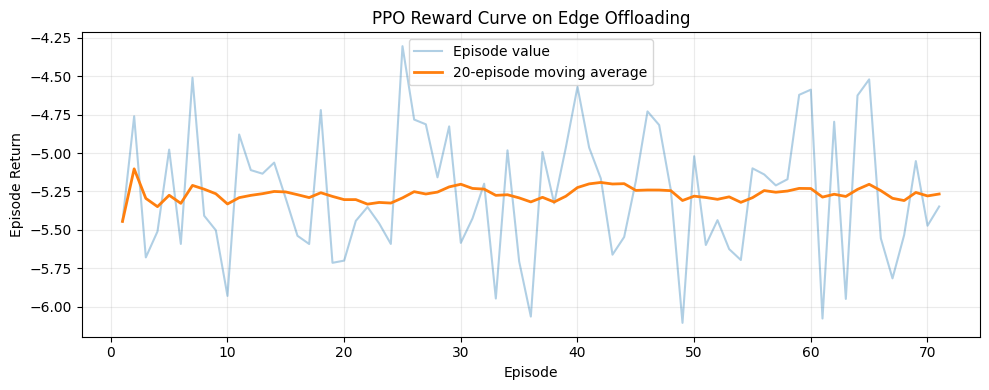

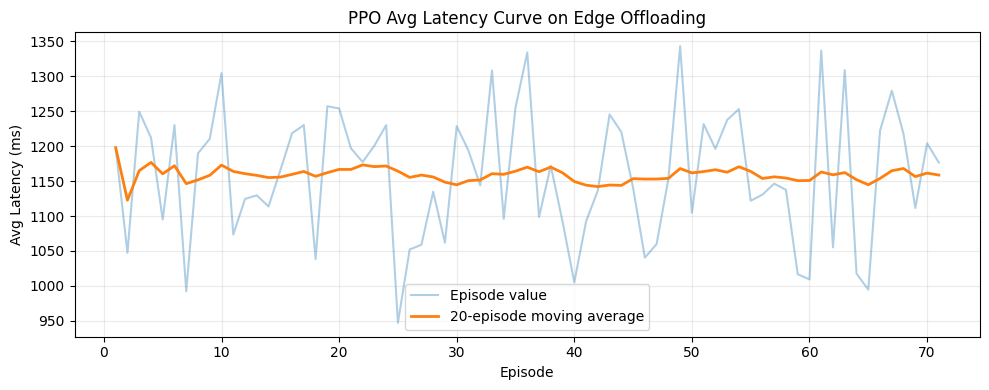

PPO evaluation summary:
{'avg_latency': 1166.985, 'p95_latency': 2401.868, 'avg_reward': -5.304, 'device_pct': 49.84, 'edge_pct': 50.16}


In [17]:

print("\n" + "="*60)
print("PART 5: PPO ON EDGE OFFLOADING ENV")
print("="*60)

# ============================================================================
# PPO Networks and Training
# ============================================================================

class PPONetwork(nn.Module):
    def __init__(self, state_dim=4, action_dim=2, hidden_size=128):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(state_dim, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
        )
        self.policy_head = nn.Linear(hidden_size, action_dim)
        self.value_head = nn.Linear(hidden_size, 1)

    def forward(self, state_tensor):
        features = self.shared(state_tensor)
        return self.policy_head(features), self.value_head(features)


def compute_gae(rewards, dones, values, next_value, gamma=0.99, gae_lambda=0.95):
    advantages = np.zeros(len(rewards), dtype=np.float32)
    running_gae = 0.0
    values_ext = np.append(np.asarray(values, dtype=np.float32), float(next_value))

    for index in reversed(range(len(rewards))):
        not_done = 1.0 - float(dones[index])
        delta = rewards[index] + gamma * values_ext[index + 1] * not_done - values_ext[index]
        running_gae = delta + gamma * gae_lambda * not_done * running_gae
        advantages[index] = running_gae

    returns = advantages + np.asarray(values, dtype=np.float32)
    return advantages, returns.astype(np.float32)


def train_ppo_edge(
    updates=PPO_UPDATES,
    rollout_steps=PPO_ROLLOUT_STEPS,
    gamma=0.99,
    gae_lambda=0.95,
    clip_ratio=0.2,
    learning_rate=1e-4,
    epochs=4,
    minibatch_size=128,
    entropy_coef=0.01,
    value_coef=0.5,
    imitation_coef=2.0,
    early_stop_patience=4,
    min_improvement=0.05,
):
    model = PPONetwork().to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    pretrain_losses = warm_start_with_greedy_policy(
        model,
        optimizer,
        sample_count=8192,
        epochs=25,
        seed=SEED + 300,
    )
    print(f'PPO greedy warm-start final CE loss: {pretrain_losses[-1]:.4f}')
    env = make_edge_env(SEED + 5000)
    state, _ = env.reset(seed=SEED + 5000)

    completed_returns, completed_latencies, update_losses = [], [], []
    current_episode_rewards, current_episode_latencies = [], []
    best_recent_return = -np.inf
    best_update = 0
    no_improve_count = 0
    best_state_dict = {name: param.detach().cpu().clone() for name, param in model.state_dict().items()}

    for update in range(updates):
        states, actions, old_log_probs, rewards, dones, values = [], [], [], [], [], []

        for _ in range(rollout_steps):
            state_norm = normalize_state(state)
            state_tensor = torch.tensor(state_norm, dtype=torch.float32, device=device).unsqueeze(0)

            with torch.no_grad():
                logits, value = model(state_tensor)
                distribution = Categorical(logits=logits)
                action = distribution.sample()
                log_prob = distribution.log_prob(action)

            next_state, reward, terminated, truncated, info = env.step(int(action.item()))
            done = terminated or truncated

            states.append(state_norm)
            actions.append(int(action.item()))
            old_log_probs.append(float(log_prob.item()))
            rewards.append(float(reward))
            dones.append(float(done))
            values.append(float(value.item()))
            current_episode_rewards.append(float(reward))
            current_episode_latencies.append(info['latency'])

            state = next_state
            if done:
                completed_returns.append(float(np.sum(current_episode_rewards)))
                completed_latencies.append(float(np.mean(current_episode_latencies)))
                current_episode_rewards, current_episode_latencies = [], []
                state, _ = env.reset(seed=SEED + 5000 + update + len(completed_returns))

        with torch.no_grad():
            next_state_tensor = torch.tensor(normalize_state(state), dtype=torch.float32, device=device).unsqueeze(0)
            _, next_value_tensor = model(next_state_tensor)
            next_value = float(next_value_tensor.item())

        advantages, returns = compute_gae(rewards, dones, values, next_value, gamma, gae_lambda)
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        state_tensor = torch.tensor(np.asarray(states), dtype=torch.float32, device=device)
        action_tensor = torch.tensor(actions, dtype=torch.long, device=device)
        old_log_prob_tensor = torch.tensor(old_log_probs, dtype=torch.float32, device=device)
        advantage_tensor = torch.tensor(advantages, dtype=torch.float32, device=device)
        return_tensor = torch.tensor(returns, dtype=torch.float32, device=device)

        sample_count = state_tensor.shape[0]
        indices = np.arange(sample_count)
        batch_losses = []

        for _ in range(epochs):
            np.random.shuffle(indices)
            for start in range(0, sample_count, minibatch_size):
                batch_idx = indices[start:start + minibatch_size]
                batch_states = state_tensor[batch_idx]
                batch_actions = action_tensor[batch_idx]
                batch_old_log_probs = old_log_prob_tensor[batch_idx]
                batch_advantages = advantage_tensor[batch_idx]
                batch_returns = return_tensor[batch_idx]

                logits, values_pred = model(batch_states)
                distribution = Categorical(logits=logits)
                new_log_probs = distribution.log_prob(batch_actions)
                entropy = distribution.entropy().mean()

                ratio = torch.exp(new_log_probs - batch_old_log_probs)
                unclipped = ratio * batch_advantages
                clipped = torch.clamp(ratio, 1.0 - clip_ratio, 1.0 + clip_ratio) * batch_advantages
                policy_loss = -torch.min(unclipped, clipped).mean()
                value_loss = nn.MSELoss()(values_pred.squeeze(-1), batch_returns)
                imitation_targets = greedy_targets_from_normalized_tensor(batch_states)
                imitation_loss = nn.CrossEntropyLoss()(logits, imitation_targets)
                loss = policy_loss + value_coef * value_loss - entropy_coef * entropy + imitation_coef * imitation_loss

                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 0.5)
                optimizer.step()
                batch_losses.append(float(loss.item()))

        update_losses.append(float(np.mean(batch_losses)))

        recent_return = np.mean(completed_returns[-10:]) if completed_returns else np.nan
        recent_latency = np.mean(completed_latencies[-10:]) if completed_latencies else np.nan

        if not np.isnan(recent_return):
            if recent_return > best_recent_return + min_improvement:
                best_recent_return = recent_return
                best_update = update + 1
                no_improve_count = 0
                best_state_dict = {name: param.detach().cpu().clone() for name, param in model.state_dict().items()}
            else:
                no_improve_count += 1

        if (update + 1) % 5 == 0 or update == 0:
            print(
                f'PPO update {update + 1:03d}/{updates} | '
                f'recent_return={recent_return:.3f} | '
                f'recent_latency={recent_latency:.2f}ms | '
                f'loss={update_losses[-1]:.4f}'
            )

        if (update + 1) >= 5 and no_improve_count >= early_stop_patience:
            print(
                f'PPO early stopping at update {update + 1}; '
                f'restored best checkpoint from update {best_update} '
                f'(recent_return={best_recent_return:.3f}).'
            )
            break

    env.close()
    model.load_state_dict(best_state_dict)
    return model, {
        'episode_rewards': np.array(completed_returns, dtype=np.float32),
        'episode_avg_latencies': np.array(completed_latencies, dtype=np.float32),
        'losses': np.array(update_losses, dtype=np.float32),
    }


def ppo_policy_action(state, env, model):
    state_tensor = torch.tensor(normalize_state(state), dtype=torch.float32, device=device).unsqueeze(0)
    with torch.no_grad():
        logits, _ = model(state_tensor)
    return int(torch.argmax(logits, dim=1).item())


ppo_model, ppo_training = train_ppo_edge()

ppo_results = evaluate_edge_policy(
    lambda seed: make_edge_env(seed),
    lambda state, env: ppo_policy_action(state, env, ppo_model),
    episodes=EVAL_EPISODES,
)

plot_curve(ppo_training['episode_rewards'], 'PPO Reward Curve on Edge Offloading', 'Episode Return', window=20)
plot_curve(ppo_training['episode_avg_latencies'], 'PPO Avg Latency Curve on Edge Offloading', 'Avg Latency (ms)', window=20)

print('PPO evaluation summary:')
print({
    'avg_latency': round(ppo_results['avg_latency'], 3),
    'p95_latency': round(ppo_results['p95_latency'], 3),
    'avg_reward': round(ppo_results['avg_reward'], 3),
    'device_pct': round(ppo_results['device_pct'], 2),
    'edge_pct': round(ppo_results['edge_pct'], 2),
})


---

# PART 6: Final Comparison

We compare all methods (baseline policies, Actor-Critic, and A2C) using shared evaluation metrics.

### 6.1 Aggregated Results Table


Final comparison table:


,Method,Avg Latency (ms),P95 Latency (ms),Avg Reward,Device %,Edge %,Gap to Greedy (ms)
0,Greedy latency,1146.595,2367.024,-5.212,48.68,51.32,0.000
1,A2C,1166.890,2402.071,-5.304,47.88,52.12,20.295
2,PPO,1166.985,2401.868,-5.304,49.84,50.16,20.390
3,Device-only,1547.224,2848.061,-7.033,100.00,0.00,400.629
4,Random,1651.593,3196.881,-7.507,48.88,51.12,504.998
5,Edge-only,1762.061,4489.290,-8.009,0.00,100.00,615.466



Training stability summary:


,Algorithm,Avg Train Return,Std Train Return,Max Train Return,Final 20-ep Avg Return
0,A2C,-5.632,0.487,-4.416,-5.651
1,PPO,-5.266,0.422,-4.304,-5.267


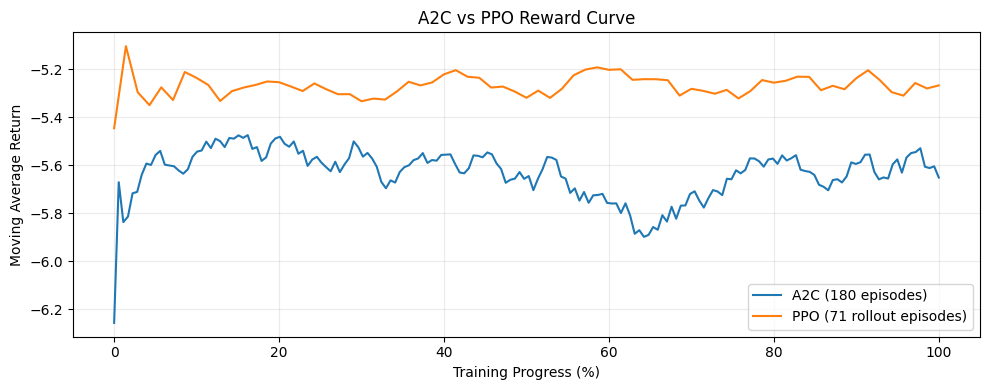

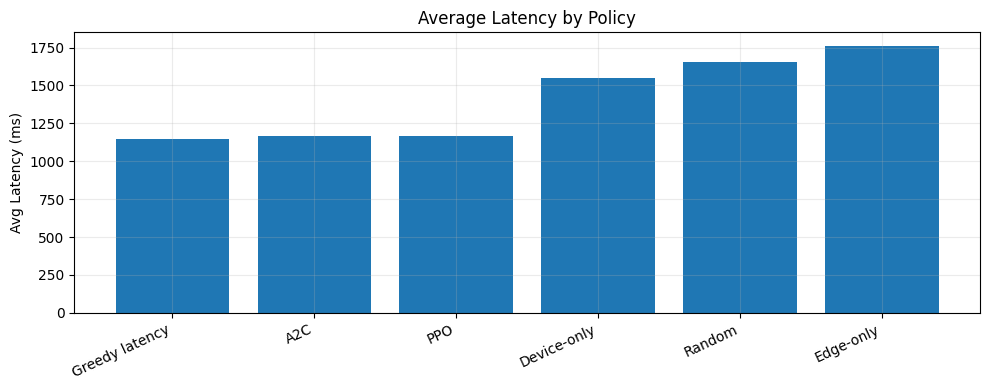

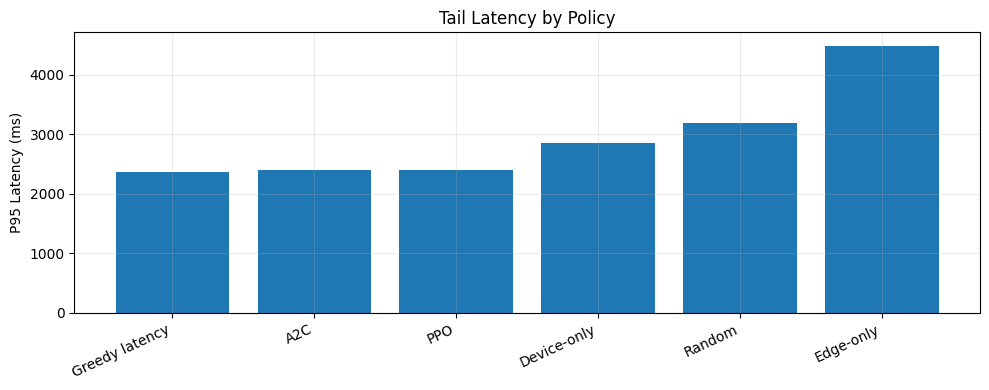

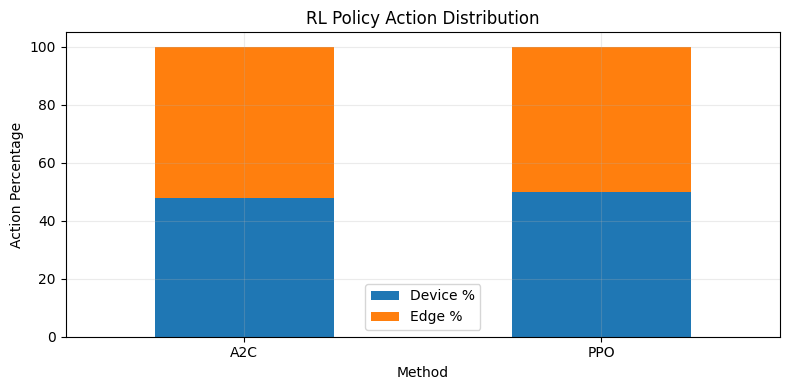

Best learned policy: A2C with avg latency 1166.89 ms and gap to greedy 20.29 ms.


In [18]:

# ============================================================================
# Build comprehensive comparison table
# ============================================================================

all_results = {
    **baseline_results,
    'A2C': a2c_results,
    'PPO': ppo_results,
}

greedy_latency = all_results['Greedy latency']['avg_latency']
comparison_rows = []
for method_name, result in all_results.items():
    comparison_rows.append({
        'Method': method_name,
        'Avg Latency (ms)': result['avg_latency'],
        'P95 Latency (ms)': result['p95_latency'],
        'Avg Reward': result['avg_reward'],
        'Device %': result['device_pct'],
        'Edge %': result['edge_pct'],
        'Gap to Greedy (ms)': result['avg_latency'] - greedy_latency,
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values('Avg Latency (ms)').reset_index(drop=True)
print('Final comparison table:')
display(comparison_df.round(3))

training_summary_df = pd.DataFrame([
    {
        'Algorithm': 'A2C',
        'Avg Train Return': float(np.mean(a2c_training['episode_rewards'])),
        'Std Train Return': float(np.std(a2c_training['episode_rewards'])),
        'Max Train Return': float(np.max(a2c_training['episode_rewards'])),
        'Final 20-ep Avg Return': float(np.mean(a2c_training['episode_rewards'][-20:])),
    },
    {
        'Algorithm': 'PPO',
        'Avg Train Return': float(np.mean(ppo_training['episode_rewards'])),
        'Std Train Return': float(np.std(ppo_training['episode_rewards'])),
        'Max Train Return': float(np.max(ppo_training['episode_rewards'])),
        'Final 20-ep Avg Return': float(np.mean(ppo_training['episode_rewards'][-20:])),
    },
])

print('\nTraining stability summary:')
display(training_summary_df.round(3))

a2c_reward_curve = moving_average(a2c_training['episode_rewards'], 20)
ppo_reward_curve = moving_average(ppo_training['episode_rewards'], 20)
a2c_progress = np.linspace(0, 100, len(a2c_reward_curve))
ppo_progress = np.linspace(0, 100, len(ppo_reward_curve))

plt.figure(figsize=(10, 4))
plt.plot(a2c_progress, a2c_reward_curve, label=f'A2C ({len(a2c_reward_curve)} episodes)')
plt.plot(ppo_progress, ppo_reward_curve, label=f'PPO ({len(ppo_reward_curve)} rollout episodes)')
plt.title('A2C vs PPO Reward Curve')
plt.xlabel('Training Progress (%)')
plt.ylabel('Moving Average Return')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.bar(comparison_df['Method'], comparison_df['Avg Latency (ms)'])
plt.xticks(rotation=25, ha='right')
plt.ylabel('Avg Latency (ms)')
plt.title('Average Latency by Policy')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.bar(comparison_df['Method'], comparison_df['P95 Latency (ms)'])
plt.xticks(rotation=25, ha='right')
plt.ylabel('P95 Latency (ms)')
plt.title('Tail Latency by Policy')
plt.tight_layout()
plt.show()

rl_action_df = comparison_df[comparison_df['Method'].isin(['A2C', 'PPO'])].set_index('Method')[['Device %', 'Edge %']]
rl_action_df.plot(kind='bar', stacked=True, figsize=(8, 4))
plt.ylabel('Action Percentage')
plt.title('RL Policy Action Distribution')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

best_rl = comparison_df[comparison_df['Method'].isin(['A2C', 'PPO'])].sort_values('Avg Latency (ms)').iloc[0]
print(
    f"Best learned policy: {best_rl['Method']} with avg latency "
    f"{best_rl['Avg Latency (ms)']:.2f} ms and gap to greedy "
    f"{best_rl['Gap to Greedy (ms)']:.2f} ms."
)


## CONGRATULATIONS TEAM!

Congratulations on Completing **Lab 05.2 – Continuous and Policy-Based RL with DDPG and PPO**!

**Key Conclusions:**

- You successfully designed and validated an **EdgeOffloadingEnv** that models realistic latency-aware offloading decisions.
- Baseline policies (random, device-only, edge-only, greedy) provided strong reference points for RL performance.
- **Actor-Critic/A2C-style methods** improved learning stability versus pure policy-gradient updates.
- **PPO** demonstrated robust and sample-efficient policy improvement through clipped objective optimization.
- Across experiments, learned policies captured the core trade-off between **local execution cost** and **edge transmission/queue delay**.

**Why This Lab Is Important:**

- It connects RL theory to a practical networking scenario: adaptive edge offloading.
- It shows how policy-based methods can outperform static heuristics in dynamic environments.
- It builds a strong foundation for deploying more advanced RL approaches in real-world edge/cloud systems.

### References

- Schulman et al., Proximal Policy Optimization Algorithms, arXiv:1707.06347
- Schulman et al., High-Dimensional Continuous Control Using GAE, ICLR 2016
- PyTorch documentation: https://pytorch.org/

## ADDITIONAL INFORMATION

**Author**: M.Sc. Phan Trung Phat - Department of Computer Networks and Communications, UIT

**Contact**: phatpt@uit.edu.vn

**Last Updated**: March, 2026